In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import utils
import matplotlib.pyplot as plt
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

## Regions of Interest

In [2]:
# Regions of interest (permanently shadowed regions)
regions_psr_df = pd.read_excel("data/permanently-shadowed-regions.xlsx")
lats_psr = regions_psr_df["Cent. Lat."].values
lons_psr = regions_psr_df["Cent. Long."].values - 180
areas_psr = regions_psr_df["Area (km2)"].values
coverage_psr = regions_psr_df["Coverage (%)"].values
alts_psr = np.zeros_like(lats_psr)
regions_psr_df.head()

,PSR ID,Cent. Lat.,Cent. Long.,Area (km2),Perimeter (km),Features of Interest,Lunar Features,Coverage (%),Data Quality
0,SP_896450_1282030,-89.645,128.203,233.698,70.32,"2012-258 (M1102304370R): 129.549, -89.632 (S80...",Shackleton Crater,65,1.0
1,SP_895060_2806850,-89.506,280.685,53.262,45.48,NaN,de Gerlache Crater Shackleton Crater,0,NaN
2,SP_890390_3377770,-89.039,337.777,60.358,54.24,NaN,Haworth Crater Shackleton Crater,0,NaN
3,SP_889970_3170870,-88.997,317.087,44.284,49.56,NaN,de Gerlache Crater Haworth Crater,0,NaN
4,SP_889970_0191990,-88.997,19.199,55.408,36.84,NaN,Haworth Crater Shackleton Crater,10,1.0


In [3]:
# Regions of interest (impact craters)
regions_ic_df = pd.read_excel(
    "data/Lunar_Impact_Crater_Database_v08Sep2015.xls", sheet_name="Database"
)
regions_ic_df = regions_ic_df[regions_ic_df["3. Latitude [°]"] <= 90]
lats_ic = regions_ic_df["3. Latitude [°]"].values
lons_ic = regions_ic_df["4. Longitude [°]"].values
areas_ic = np.pi * np.square(regions_ic_df["6. Radius [km]"].values)
alts_ic = np.zeros_like(lats_ic)
regions_ic_df.head()

,1. Crater name,2. Diameter [km],3. Latitude [°],4. Longitude [°],5. East longitude [°],6. Radius [km],7. Radius [m],8. Apparent diameter [km],9. Transient cavity diameter [km],10. Transient cavity diameter [km],...,73. Average CF [μm],74. Average OMAT,75. Average FeO [wt.-%],76. OMAT range,77. Plg abundance class,78. Province,79. Peak degradation,80. PAN location,81. Rays,1. Crater name .1
0,Abbe,63.98,-57.58,174.77,174.77,31.990,31990.0,55.0228,51.469659,37.371461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe
1,Abbe H,25.13,-58.44,177.58,177.58,12.565,12565.0,21.6118,23.258264,15.604124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe H
2,Abbe K,26.10,-59.82,176.86,176.86,13.050,13050.0,22.4460,24.019177,16.166327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe K
3,Abbe M,28.61,-61.75,175.24,175.24,14.305,14305.0,24.6046,25.968919,17.614889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe M
4,Abbot,10.40,5.56,54.74,54.74,5.200,5200.0,8.6320,8.736000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbot


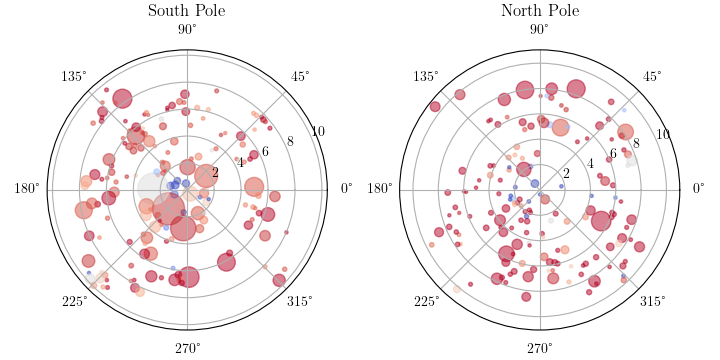

In [4]:
plot_scale = 0.5
fig_scale = 0.02

fig = plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
# Polar plot (South pole)
ax = fig.add_subplot(121, polar=True)
idxs = lats_psr < 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 + lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("South Pole")

# Polar plot (North pole)
ax = fig.add_subplot(122, polar=True)
idxs = lats_psr > 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 - lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("North Pole")
plt.savefig("figures/psr.pdf")
plt.tight_layout()
plt.show()

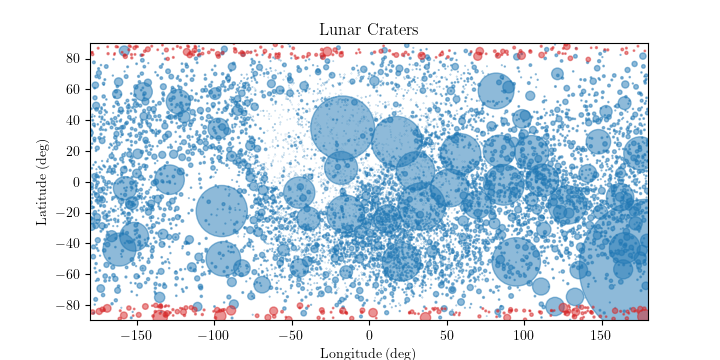

In [5]:
plot_scale = 0.002
fig_scale = 0.02
plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
plt.scatter(lons_ic, lats_ic, s=areas_ic * plot_scale, alpha=0.5, c="tab:blue")
plt.scatter(
    lons_psr,
    lats_psr,
    c="tab:red",
    s=areas_psr * plot_scale * 50,
    alpha=0.5,
)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Lunar Craters")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
p1 = plt.Circle((0, 0), 90, color="tab:blue", alpha=0.5)
p2 = plt.Circle((0, 0), 90, color="tab:red", alpha=0.5)
plt.legend(
    [p1, p2],
    ["Impact Craters", "Permanently Shadowed Regions"],
    loc="center left",
    ncol=2,
    bbox_to_anchor=(0.1, -0.25),
)
plt.savefig("figures/craters.pdf")
plt.show()

In [6]:
lats = np.concatenate([lats_ic, lats_psr])
lons = np.concatenate([lons_ic, lons_psr])
alts = np.concatenate([alts_ic, alts_psr])

# Satellite

In [48]:
# Epoch
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")

# Orbital elements
sma = 5740  # [km]  a, Semi-major axis
ecc = 0.58  # [-]   e, Eccentricity
inc = np.deg2rad(54.856)  # [rad] i, Inclination
raan = np.deg2rad(0)  # [rad] W, Right ascension of the ascending node
aop = np.deg2rad(86.322)  # [rad] w, Argument of periapsis
ma = np.deg2rad(0)  # [rad] M, Mean anomaly
coe_sat_OP = np.array([sma, ecc, inc, raan, aop, ma])
rv0_sat_OP = pnt.classical_to_cartesian(coe_sat_OP, pnt.MU_MOON)
rv0_sat_mi = pnt.CoordConverter.convert(epoch_0, rv0_sat_OP, pnt.OP, pnt.MI)

# Time
T = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)
Dt = 5 * pnt.SECS_PER_MINUTE
dt = 5 * pnt.SECS_PER_MINUTE
tf = 2.5 * pnt.SECS_PER_DAY
N_t = int(tf / Dt)
tspan = np.linspace(0, tf, N_t)

# Dynamics
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

In [8]:
# Propagation
rv_moon_sat_mi = dynamics.propagate(rv0_sat_mi, epoch_0, epoch_0 + tspan)
rv_earth_sat_eci = pnt.CoordConverter.convert(
    epoch_0 + tspan, rv_moon_sat_mi, pnt.MI, pnt.ECI
)
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(
    epoch_0 + tspan, pnt.MOON, pnt.EARTH
)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epoch_0 + tspan, pnt.MOON, pnt.SUN)

In [9]:
# Locations
N_loc = 10
np.random.seed(0)
idxs_south_pole = np.where(lats < -60)[0]
idxs = np.random.choice(idxs_south_pole, N_loc)
loc_lats = np.deg2rad(lats[idxs])
loc_lons = np.deg2rad(lons[idxs])
loc_alts = alts[idxs]

r_obs_pa = pnt.geographical_to_cartesian(
    np.vstack((loc_lats, loc_lons, loc_alts)).T, pnt.R_MOON
)
rv_obs_pa = np.hstack((r_obs_pa, np.zeros((N_loc, 3))))
rv_obs_mi = pnt.CoordConverter.convert(epoch_0, rv_obs_pa, pnt.PA, pnt.MI)

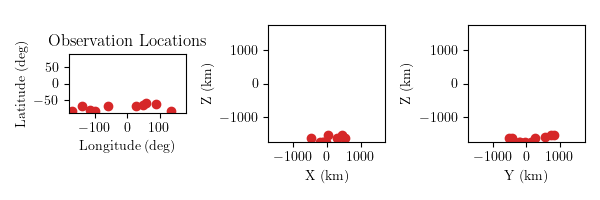

In [10]:
# Lat-lon and position in PA frame
plt.figure(figsize=(6, 2))
plt.subplot(131)
plt.plot(np.rad2deg(loc_lons), np.rad2deg(loc_lats), "o", color="tab:red")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Observation Locations")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(132)
plt.plot(r_obs_pa[:, 0], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(133)
plt.plot(r_obs_pa[:, 1], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

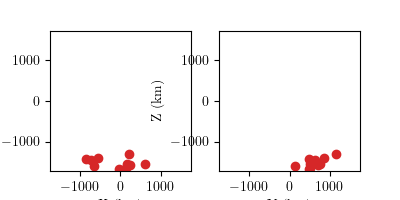

In [11]:
# Position in MI frame
plt.figure(figsize=(4, 2))
plt.subplot(121)
plt.plot(rv_obs_mi[:, 0], rv_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(122)
plt.plot(rv_obs_mi[:, 1], rv_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

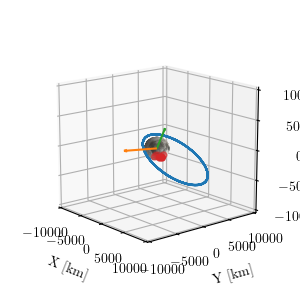

In [12]:
# Satellite orbit in MI frame
fig = pnt.plots.Plot3D(figsize=(3, 3), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv_moon_sat_mi[:, 0:3], label="Satellite", color="tab:blue", mask=False)
fig.scatter(
    rv_obs_mi[:, 0:3], label="Observation Locations", color="tab:red", mask=False
)

# Earth and Sun positions
earth_dir = rv_moon_earth_mi[0, 0:3]
earth_dir = earth_dir / np.linalg.norm(earth_dir) * 3 * pnt.R_MOON
sun_dir = rv_moon_sun_mi[0, 0:3]
sun_dir = sun_dir / np.linalg.norm(sun_dir) * 3 * pnt.R_MOON
org = np.zeros(3)
fig.ax.quiver(*org, *earth_dir, color="tab:green", label="Earth", arrow_length_ratio=0.1)
fig.ax.quiver(*org, *sun_dir, color="tab:orange", label="Sun", arrow_length_ratio=0.1)

# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
plt.savefig("figures/obs_locations.pdf")
plt.show()

# Moon Locations

In [13]:
rv_loc_sat_mi = np.zeros((N_loc, N_t, 6))
az_el_rho = np.zeros((N_loc, N_t, 3))
for i in range(N_loc):
    rv_loc_sat_mi[i, :, :] = rv_moon_sat_mi - rv_obs_mi[i, :]
    az_el_rho[i, :, :] = pnt.cartesian_to_azimuth_elevation_range(
        rv_obs_mi[i, :3], rv_moon_sat_mi[:, :3]
    )

In [14]:
# Max elevation for each location
max_elevation = np.max(az_el_rho[:, :, 1], axis=1)
min_elev = np.deg2rad(10)
min_elevevation = np.maximum(min_elev, max_elevation - np.deg2rad(10))
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevevation).round(0))

user_visible = np.greater_equal(az_el_rho[:, :, 1], min_elevevation[:, None])
print(user_visible.shape)

Max elevation (geometry)    [37. 51. 15. 11. 62. 32. 43. 22. 60. 49.]
Min elevation (requirement) [27. 41. 10. 10. 52. 22. 33. 12. 50. 39.]
(10, 720)


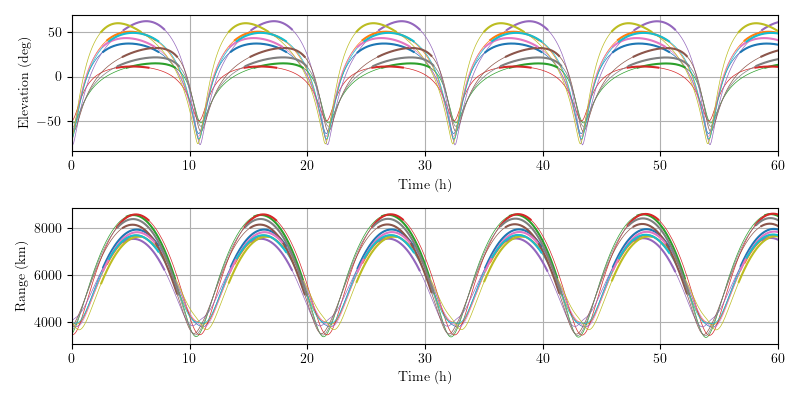

In [15]:
# Elevation and range over time
plt.figure(figsize=(8, 4))
x = tspan / pnt.SECS_PER_HOUR
x_lim = (0, tspan[-1] / pnt.SECS_PER_HOUR)

plt.subplot(211)
el = np.rad2deg(az_el_rho[:, :, 1].copy())
plt.plot(x, el.T, label="Elevation", lw=0.5)
el[~user_visible] = np.nan
plt.plot(x, el.T, lw=1.5)
plt.xlabel("Time (h)")
plt.ylabel("Elevation (deg)")
plt.xlim(x_lim)
plt.grid()
plt.subplot(212)
rho = az_el_rho[:, :, 2].copy()
plt.plot(x, rho.T, label="Range", lw=0.5)
rho[~user_visible] = np.nan
plt.plot(x, rho.T, lw=1.5)
plt.xlabel("Time (h)")
plt.ylabel("Range (km)")
plt.xlim(x_lim)
plt.grid()
plt.tight_layout()
plt.show()

# Earth Ground Stations

In [16]:
# Earth ground stations (Pathfinder document)
use_dsn = True

earth_dns_loc = np.array(
    [
        # Madrid Deep Space Communications Complex (40°25′26″N 4°15′16″W)
        [pnt.dms2degrees([40, 25, 26]), pnt.dms2degrees([4, 15, 16]), 0],
        # Goldstone Deep Space Communications Complex (35°25′36″N 116°52′58″W)
        [pnt.dms2degrees([35, 25, 36]), -pnt.dms2degrees([116, 52, 58]), 0],
        # Canberra Deep Space Communication Complex (35°24′07″S 148°58′30″E)
        [-pnt.dms2degrees([35, 24, 7]), pnt.dms2degrees([148, 58, 30]), 0],
    ]
)
earth_gs_loc = np.array(
    [
        # Goonhilly Earth Station (50°02′53″N 5°10′55″W)
        [pnt.dms2degrees([50, 2, 53]), -pnt.dms2degrees([5, 10, 55]), 0],
        # Indian Deep Space Network (12°54′06″N 77°22′05″E)
        [pnt.dms2degrees([12, 54, 6]), pnt.dms2degrees([77, 22, 5]), 0],
    ]
)
gs_names = ["Goonhilly", "Indian DSN"]
if use_dsn:
    earth_gs_loc = np.vstack((earth_gs_loc, earth_dns_loc))
    gs_names += ["Madrid DSN", "Goldstone DSN", "Canberra DSN"]

# Earth ground stations in MI frame
N_gs = len(earth_gs_loc)
earth_gs_loc[:, :2] = np.deg2rad(earth_gs_loc[:, :2])
r_earth_gs_ecef = pnt.geographical_to_cartesian(earth_gs_loc, pnt.R_EARTH)
rv_earth_gs_ecef = np.hstack((r_earth_gs_ecef, np.zeros((N_gs, 3))))
rv_earth_gs_eci = np.zeros((N_gs, N_t, 6))
rv_earth_gs_mi = np.zeros((N_gs, N_t, 6))
for i in range(N_gs):
    rv_earth_gs_eci[i, :, :] = pnt.CoordConverter.convert(
        epoch_0 + tspan, rv_earth_gs_ecef[i, :], pnt.ECEF, pnt.ECI
    )
    rv_earth_gs_mi[i, :, :] = pnt.CoordConverter.convert(
        epoch_0 + tspan, rv_earth_gs_eci[i, :, :], pnt.ECI, pnt.MI
    )

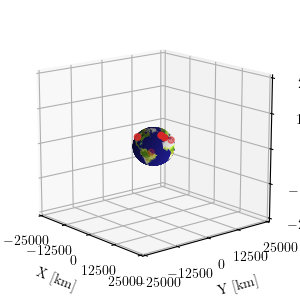

In [17]:
# Plot Earth ground stations
fig = pnt.plots.Plot3D(figsize=(3, 3), elev=15, azim=-40)
fig.plot_surface(pnt.EARTH, scale=3)
fig.label_axis()
fig.scatter(
    r_earth_gs_ecef[:, 0:3], label="Earth Ground Stations", color="tab:red", mask=False
)
# fig.ax.zaxis.labelpad = 5
plt.tight_layout()
plt.savefig("figures/Earth_gs.pdf")
plt.show()

In [20]:
# Earth and moon occultation
bodies = [pnt.EARTH]
radii = pnt.R_EARTH
idxs_occult = np.zeros((N_gs, N_t), dtype=bool)
for i_gs in range(N_gs):
    idxs_occult[i_gs, :] = np.less_equal(
        pnt.compute_occultation(
            epoch_0 + tspan,
            rv_earth_gs_mi[i_gs, :, 0:3],
            rv_moon_sat_mi[:, 0:3],
            pnt.MI,
            pnt.MI,
            bodies,
        ),
        radii * (1 - 1e-6),
    ).flatten()

# Elevation and range over time
az_el_rho_gs = np.zeros((N_gs, N_t, 3))
idxs_elev = np.zeros((N_gs, N_t), dtype=bool)
min_elev = np.deg2rad(10)
for i_gs in range(N_gs):
    az_el_rho_gs[i_gs, :, :] = pnt.cartesian_to_azimuth_elevation_range(
        rv_earth_gs_eci[i_gs, :, 0:3], rv_earth_sat_eci[:, 0:3]
    )
    idxs_elev[i_gs, :] = np.greater_equal(az_el_rho_gs[i_gs, :, 1], min_elev)

# Visibility
idxs_visible = ~idxs_occult & idxs_elev
min_duration = int(10 * pnt.SECS_PER_MINUTE / Dt)

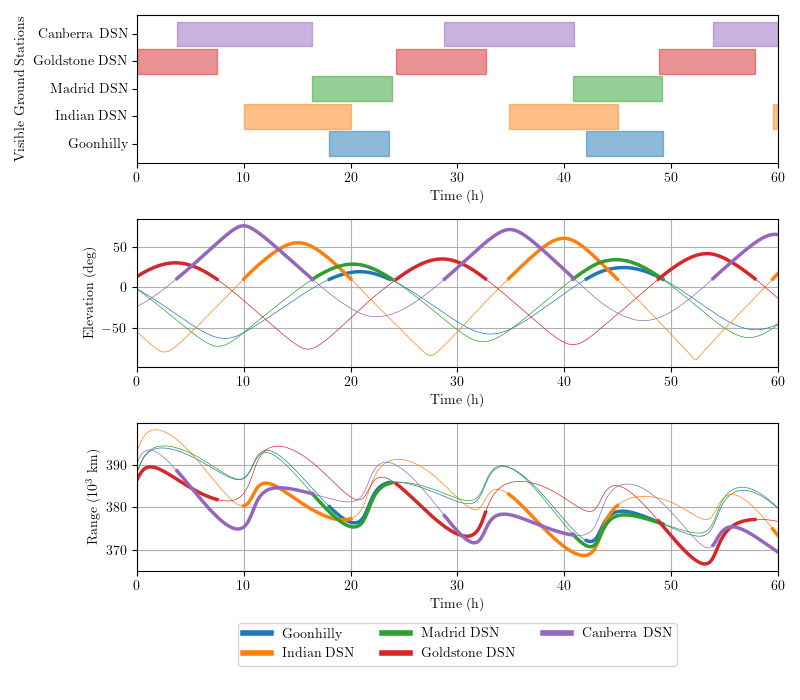

In [21]:
# Plot visibility, elevation, and range
plt.figure(figsize=(8, 7))
x = tspan / pnt.SECS_PER_HOUR

# Plot visibility
plt.subplot(311)
for i_gs in range(N_gs):
    tstarts, tends = utils.get_start_and_end_indexes(idxs_visible[i_gs])
    for ts, te in zip(tstarts, tends):
        if te - ts < min_duration:
            print(f"{gs_names[i_gs]} visible from {ts} to {te}")
        plt.fill_between(
            x[ts:te], i_gs - 0.45, i_gs + 0.45, color=pnt.plots.COLORS[i_gs], alpha=0.5
        )

plt.xlabel("Time (h)")
plt.ylabel("Visible Ground Stations")
plt.xlim(x_lim)
plt.yticks(range(N_gs), gs_names)
plt.tight_layout()

# Plot elevation
plt.subplot(312)
for i_gs in range(N_gs):
    el = np.rad2deg(az_el_rho_gs[i_gs, :, 1].copy())
    plt.plot(x, el, label=gs_names[i_gs], lw=0.5, color=pnt.plots.COLORS[i_gs])
    el[~idxs_visible[i_gs]] = np.nan
    plt.plot(x, el, lw=2.5, color=pnt.plots.COLORS[i_gs])
plt.xlabel("Time (h)")
plt.ylabel("Elevation (deg)")
plt.xlim(x_lim)
plt.grid()

# Plot range
plt.subplot(313)
for i_gs in range(N_gs):
    rho = az_el_rho_gs[i_gs, :, 2].copy() / 1e3
    plt.plot(x, rho, label=gs_names[i_gs], lw=0.5, color=pnt.plots.COLORS[i_gs])
    rho[~idxs_visible[i_gs]] = np.nan
    plt.plot(x, rho, lw=2.5, color=pnt.plots.COLORS[i_gs])
plt.xlabel("Time (h)")
plt.ylabel("Range ($10^3$ km)")
plt.xlim(x_lim)
plt.grid()

# Legend
legend_lines = [
    plt.Line2D([0], [0], color=pnt.plots.COLORS[i], lw=4, label=gs_names[i])
    for i in range(N_gs)
]
plt.legend(
    handles=legend_lines,
    loc="center",
    ncol=N_gs // 2 + 1,
    bbox_to_anchor=(0.5, -0.5),
)
plt.tight_layout()
plt.show()

# Sun Visibility

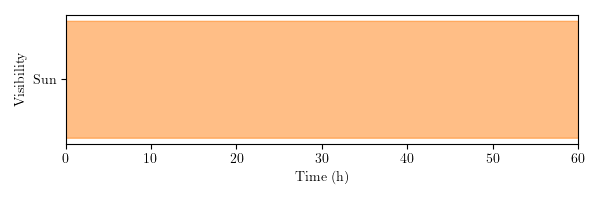

In [22]:
# Sun visibility
bodies = [pnt.EARTH, pnt.MOON]
radii = np.array([pnt.R_EARTH, pnt.R_MOON])
idxs_occult_sun = np.less_equal(
    pnt.compute_occultation(
        epoch_0 + tspan,
        rv_moon_sun_mi[:, 0:3],
        rv_moon_sat_mi[:, 0:3],
        pnt.MI,
        pnt.MI,
        bodies,
    ),
    radii * 1.1,
)

# Sun visibility
idxs_visible_sun = ~idxs_occult_sun.any(axis=1)

# Plot visibility
plt.figure(figsize=(6, 2))
x = tspan / pnt.SECS_PER_HOUR
plt.fill_between(x, -0.5, 0.5, where=idxs_visible_sun, color="tab:orange", alpha=0.5)
plt.xlabel("Time (h)")
plt.ylabel("Visibility")
plt.xlim(x_lim)
plt.yticks([0], ["Sun"])
plt.tight_layout()
plt.show()

# Link Budgets

# Scenario

User
[Opportunity(task=0, time_start=32, time_end=89, duration=24, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=42, id_count=0), Opportunity(task=1, time_start=36, time_end=86, duration=27, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=43, id_count=0), Opportunity(task=2, time_start=56, time_end=106, duration=33, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=44, id_count=0), Opportunity(task=3, time_start=46, time_end=79, duration=12, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=45, id_count=0), Opportunity(task=4, time_start=53, time_end=95, duration=15, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=46, id_count=0), Opportunity(task=5, time_start=52, time_end=108, duration=39, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=47, id_count=0), Opportunity(task=6, time_start=32, time_end=85, duration=15, power=-20, data=600.0, reward=1, type=<TaskType.USER: 0>, id=48, id_count=0), Opportunity(task=7,

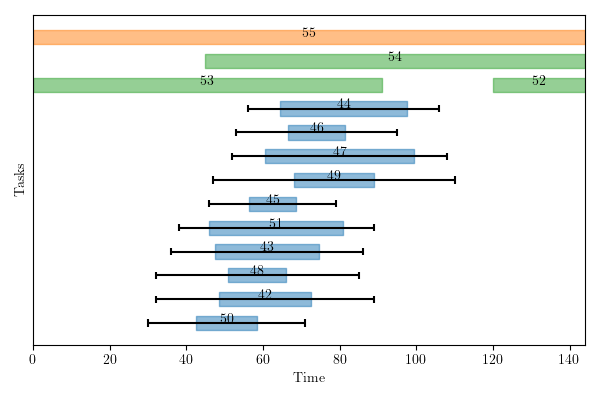

In [122]:
from utils import Opportunity, TaskType

# Create scenario 
N_t_opt = N_t // 5

solar_power = 100 # [W]

datarate_moon_fwd = 0.2 # [Mbps]
datarate_earth_fwd = 0.03 # [Mbps]

datarate_moon_rtn = 2 # [Mbps]
datarate_earth_rtn = 5 # [Mbps]

min_duration = int(1 * pnt.SECS_PER_HOUR / Dt)
max_duration = int(8 * pnt.SECS_PER_HOUR / Dt)

np.random.seed(0)

# User opportunities
user_opportunities = []
for i_loc in range(N_loc):
    tstarts, tends = utils.get_start_and_end_indexes(user_visible[i_loc, :N_t_opt])
    max_duration_i = int(np.minimum(0.75 * np.min(tends - tstarts), max_duration))
    duration = np.random.randint(min_duration, max_duration_i) # [steps]
    power = -20 # [W]
    data = datarate_moon_rtn * Dt # [Mbps]
    for ts, te in zip(tstarts, tends):
        user_opportunities.append(
            Opportunity(i_loc, ts, te, duration, power, data, type=TaskType.USER)
        )
print("User")
print(user_opportunities)

# Downlink opportunities
downlink_opportunities = []
for i_gs in range(N_gs):
    tstarts, tends = utils.get_start_and_end_indexes(idxs_visible[i_gs, :N_t_opt])
    datarate = -datarate_earth_rtn * Dt # [Mbps]
    power = -20 # [W]
    duration = 1 # [steps]
    for ts, te in zip(tstarts, tends):
        downlink_opportunities.append(
            Opportunity(i_gs, ts, te, duration, power, datarate, type=TaskType.DOWNLINK)
        )
print("Downlink")
print(downlink_opportunities)

# Sun pointing opportunities
sun_pointing_opportunities = []
tstarts, tends = utils.get_start_and_end_indexes(idxs_visible_sun[:N_t_opt])
duration = 1 # [steps]
power = solar_power # [W]
for ts, te in zip(tstarts, tends):
    sun_pointing_opportunities.append(
        Opportunity(0, ts, te, duration, power, 0, type=TaskType.SUN_POINTING)
    )
print("Sun pointing")
print(sun_pointing_opportunities)

# Create scenario
opportunities = user_opportunities + downlink_opportunities + sun_pointing_opportunities

plt.figure(figsize=(6, 4))
utils.plot_opportunity_windows(opportunities, plot_all=True)
plt.tight_layout()
plt.savefig("figures/tasks.pdf")
plt.show()

In [123]:
import math
import cvxpy as cp

data_min = 0
data_max = 10 * 8 * 1e3 # [Mb]
data_initial = data_max / 2

power_min = 0 # [W]
power_max = 5000 # [W]
power_initial = power_max / 2
 
N_o = len(opportunities)
lambda_data = 0.01 / data_max
lambda_power = 0.01 / power_max

# Variables
opp_selected = cp.Variable(N_o, boolean=True)
opp_start_times = cp.Variable((N_o, N_t_opt), boolean=True)
opp_times = cp.Variable((N_o, N_t_opt), boolean=True)

# Resources
data_array = np.array([[op.data] for op in opportunities])
power_array = np.array([[op.power] for op in opportunities])
data_var = cp.sum(cp.multiply(opp_times, data_array), axis=0)
power_var = cp.sum(cp.multiply(opp_times, power_array), axis=0)
lower_diag = np.tril(np.ones((N_t_opt, N_t_opt)), k=0)

# Rewards
rewards = np.array([op.reward for op in opportunities])

# Objective
objective = cp.Maximize(
    rewards @ opp_selected
    - lambda_data * cp.max(lower_diag @ data_var)
    + lambda_power * cp.min(lower_diag @ power_var)
)
# Constraints

constraints = []
for i, opp in enumerate(opportunities):
    # Opportunity times
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    Dt_opp = math.ceil(opp.duration)
    print(opp.id, ts, te, Dt_opp)

    # Valid times
    constraints.append(opp_times[i, ts:te] <= opp_selected[i])
    if ts > 0:
        constraints.append(opp_times[i, :ts] == 0)
    if te < N_t_opt:
        constraints.append(opp_times[i, te:] == 0)

    # Duration constraint
    if opp.type == TaskType.USER:
        # Valid start
        constraints.append(opp_start_times[i, ts : te - Dt_opp + 1] <= opp_selected[i])
        if ts > 0:
            constraints.append(opp_start_times[i, :ts] == 0)
        if te < N_t_opt:
            constraints.append(opp_start_times[i, te - Dt_opp + 1 :] == 0)
        constraints.append(
            cp.sum(opp_start_times[i, ts : te - Dt_opp + 1]) == opp_selected[i]
        )

        # Total duration
        constraints.append(
            cp.sum(opp_times[i, ts:te]) == opp.duration * opp_selected[i]
        )

        for t in range(ts, te - Dt_opp + 1):
            constraints.append(opp_times[i, t : t + Dt_opp] >= opp_start_times[i, t])
            if t > ts:
                constraints.append(opp_times[i, ts:t] <= 1 - opp_start_times[i, t])
            if t + Dt_opp < te:
                constraints.append(
                    opp_times[i, t + Dt_opp : te] <= 1 - opp_start_times[i, t]
                )

    else:
        constraints.append(cp.sum(opp_times[i, :]) >= opp_selected[i])
        constraints.append(cp.sum(opp_times[i, :]) <= N_t_opt * opp_selected[i])
# One task per time
constraints.append(cp.sum(opp_times, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)

# Problem
problem = cp.Problem(objective, constraints)

42 32 89 24
43 36 86 27
44 56 106 33
45 46 79 12
46 53 95 15
47 52 108 39
48 32 85 15
49 47 110 21
50 30 71 16
51 38 89 35
52 120 144 1
53 0 91 1
54 45 144 1
55 0 144 1


In [124]:
# Solve
problem.solve(verbose=True)
print("Problem status:", problem.status)
print("Objective value:", problem.value)
print("Selected opportunities:")
print(opp_selected.value.astype(int))
print("Times:")
print(opp_times.value.astype(int))

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Feb 20 12:51:23 AM: Your problem has 4046 variables, 887 constraints, and 0 parameters.


(CVXPY) Feb 20 12:51:23 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 20 12:51:23 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 20 12:51:23 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 20 12:51:23 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 20 12:51:23 AM: Compiling problem (target solver=SCIPY).
(CVXPY) Feb 20 12:51:23 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCIPY
(CVXPY) Feb 20 12:51:23 AM: Applying reduction FlipObjective
(CVXPY) Feb 20 12:51:23 AM: Applying reduction Dcp2Cone
(CVXPY) Feb 20 12:

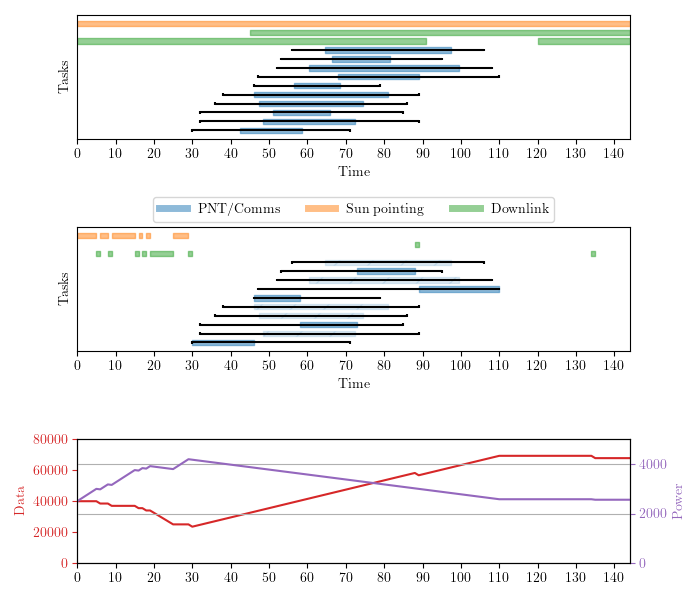

In [125]:
start_end_times = {}
for i, opp in enumerate(opportunities):
    if opp_selected.value[i]:
        tstart, tend = utils.get_start_and_end_indexes(
            np.round(opp_times.value[i, :], 0)
        )
        start_end_times[opp.id] = (tstart, tend)

xticks = np.arange(N_t_opt + 1, step=10)
# Schedule
plt.figure(figsize=(7, 6))
plt.subplot(311)
utils.plot_opportunity_windows(opportunities, plot_all=True, plot_labels=False)
plt.xticks(xticks)

plt.subplot(312)
utils.plot_opportunity_windows(
    opportunities, start_end_times, plot_all=True, plot_labels=False
)
plt.xticks(xticks)

# Resources
plt.subplot(313)
t_plot = np.arange(N_t_opt + 1)

# Left axis
ax = plt.gca()
color = utils.TABLEAU_COLORS[3]
data_plot = np.append([data_initial], lower_diag @ data_var.value + data_initial)
ax.plot(t_plot, data_plot, label="Data", color=color)
# ax.hlines([data_min, data_max], 0, N_t, color=color, linestyle="--")
ax.set_ylabel("Data [MB]", color=color)
ax.tick_params(axis="y", colors=color)
ax.set_ylim(data_min, data_max)

# Right axis
ax = ax.twinx()
color = utils.TABLEAU_COLORS[4]
power_plot = np.append([power_initial], lower_diag @ power_var.value + power_initial)
ax.plot(t_plot, power_plot, label="Power", color=color)
# ax.hlines([power_min, power_max], 0, N_t, color=color, linestyle=":")
ax.set_ylabel("Power [Wh]", color=color)
ax.tick_params(axis="y", colors=color)
ax.set_ylim(power_min, power_max)

ax.set_xlabel("Time")
ax.set_xlim(0, N_t_opt)
ax.set_xticks(xticks)
ax.grid()

plt.tight_layout()
plt.savefig("figures/schedule.pdf")
plt.show()

In [126]:
# Constraints
constraints = [opp_selected.value[0] == 1]
for i, opp in enumerate(opportunities):
    # Start and end times
    valid_times = np.zeros(N_t_opt)
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    valid_times[ts:te] = 1
    constraints.append(opp_times.value[i, :] <= valid_times * opp_selected.value[i])
    # Duration constraint
    if opp.type == TaskType.USER:
        constraints.append(
            np.sum(opp_times.value[i, :]) == opp.duration * opp_selected.value[i]
        )
    else:
        constraints.append(np.sum(opp_times.value[i, :]) >= opp_selected.value[i])
        constraints.append(np.sum(opp_times.value[i, :]) <= N_t_opt * opp_selected.value[i])
# One task per time
data_var = np.sum(np.multiply(opp_times.value, data_array), axis=0)
power_var = np.sum(np.multiply(opp_times.value, power_array), axis=0)
constraints.append(np.sum(opp_times.value, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)
print(np.min([np.min(c) for c in constraints]))

False


# Forward Search

In [18]:
from SatelliteTaskingMdp import SatelliteTaskingMdp, SmdpForwardSearch, SatelliteState

planning_horizon = 7
solve_depth = 15
discount_factor = 0.9
model = SatelliteTaskingMdp()
solver = SmdpForwardSearch(model)
state = SatelliteState(0, set(opportunities), data_initial, power_initial)
policy = solver.solve(state, solve_depth, discount_factor)

UnboundLocalError: cannot access local variable 'opportunities' where it is not associated with a value

In [ ]:
for s, a in policy:
    print(s.time, a.opportunity.id)

0 0
1 3
2 1


In [ ]:
model_py = SatelliteTaskingProblem()
model_gen = MDP.GenerativeModelPython(model_py)

n_iterations = 100
exploration_constant = 5.0
model_mcts = MDP.MCTSGenerativeModelPython(
    model_gen, n_iterations, exploration_constant
)

NameError: name 'SatelliteTaskingProblem' is not defined

In [ ]:
i, opp = 0, opportunities[0]
# Start and end times
valid_times = np.zeros(N_t)
ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
valid_times[ts:te] = 1
print(opp_times.value[:, i] <= valid_times * opp_selected.value[i])

ValueError: operands could not be broadcast together with shapes (7,) (8,) 